In [44]:
import numpy as np
import pandas as pd
from scipy.optimize import root
from scipy.special import kv

# ==========================================================
# FILE INPUT
# ==========================================================
file_linee = "Tab_completa_revisione.csv"
file_transizioni = "dati.asc"
#file_mcmc = "risultati_MCMC.csv"
file_mcmc= "risultati_MCMC_linee_eliminate.csv"   #in questo caso, ho fatto in modo che programma non calcola Cf per righe che non ho considerato in MCMc (vedi blocco analizza_blazar_doppio_ramo, dopo df_linee)

# soglia che separa i due regimi
MDOT_SWITCH = 1e-2

# ==========================================================
# COSTANTI FISICHE E PARAMETRI SHAKURA-SUNYAEV
# ==========================================================
c = 2.99792458e10
G = 6.67430e-8
h = 6.62607015e-27
kB = 1.380649e-16
sigma = 5.670374419e-5
Msun = 1.98847e33
eta = 0.083
Nr = 2000
Nnu = 400
nu_min_SS = 1e13
nu_max_SS = 1e17


# ==========================================================
# PARAMETRI ADAF
# ==========================================================

ALFA = 0.3
RMIN = 3.0
RMAX = 1000.0
DELTA = 0.0
C1 = 0.5
C3 = 0.3
TNORM = 1.68e-10
beta_default = 0.5


# ==========================================================
# FUNZIONI SS
# ==========================================================
def costruisci_spettro_disco_SS(
    MBH_solar,
    mdot,
    eta=0.083,
    Nr=2000,
    Nnu=400,
    nu_min=1e13,
    nu_max=1e17
):

    # massa del BH in grammi
    MBH = MBH_solar * Msun

    # luminosità di Eddington
    Ledd = 1.3e38 * MBH_solar

    # luminosità del disco
    Ldisk = mdot * Ledd

    # accretion rate fisico in g/s
    Mdot = Ldisk / (eta * c**2)

    # raggio di Schwarzschild
    Rs = 2 * G * MBH / c**2

    Rin = 3 * Rs
    Rout = 3000 * Rs

    # griglia radiale
    R = np.logspace(
        np.log10(Rin),
        np.log10(Rout),
        Nr
    )

    # termine del bordo interno
    f = 1.0 - np.sqrt(Rin / R)
    f = np.clip(f, 0.0, None)

    # profilo di temperatura del disco
    T = (
        (3 * G * MBH * Mdot)
        / (8 * np.pi * sigma * R**3)
        * f
    )**0.25

    # griglia in frequenza
    nu = np.logspace(
        np.log10(nu_min),
        np.log10(nu_max),
        Nnu
    )

    Bnu = np.zeros((Nnu, Nr))

    # emissione di corpo nero di ciascun anello
    for j in range(Nr):

        if T[j] <= 0:
            continue

        x = h * nu / (kB * T[j])

        x = np.clip(
            x,
            1e-12,
            700.0
        )

        Bnu[:, j] = (
            2 * h * nu**3 / c**2
        ) / (
            np.exp(x) - 1.0
        )

    # integrazione su tutto il disco
    integrand = R[None, :] * Bnu

    I_nu = np.trapezoid(
        integrand,
        R,
        axis=1
    )

    Lnu = 4 * np.pi**2 * I_nu

    return nu, Lnu

# ==========================================================
# FUNZIONI ADAF
# ==========================================================
def bessk(n, x):
    return kv(n, x)


def g(teta):
    return (
        (1.0 / bessk(2, 1.0 / teta))
        * (2.0 + 2.0 * teta + 1.0 / teta)
        * np.exp(-1.0 / teta)
    )

def temperat(y, mdot, m, beta):

    ff = y[2]**2
    xm = 1e3 * y[1]**2
    teta = y[0]**2

    s1 = (
        1.42e9
        * ALFA**(-0.5)
        * np.sqrt(1 - beta)
        * C1**(-0.5)
        * C3**0.5
    )

    s2 = 1.19e-13 * xm

    q1 = (
        1.2e4
        * g(teta)
        * ALFA**(-2)
        * C1**(-2)
        * C3
        * beta
        * m
        * mdot**2
        / RMIN
    )

    q2 = (
        DELTA
        * 9.39e4
        * ((1 - beta) / ff)
        * C3
        * m
        * mdot
        / RMIN
    )

    q = q1 + q2

    nup = (
        s1
        * s2
        * m**(-0.5)
        * mdot**0.5
        * (teta / TNORM)**2
        * RMIN**(-5/4)
    )

    psinc = (
        53.0
        * (xm / 1000.0)**3
        * (teta / (1e9 * TNORM))**7
        * m**0.5
        * mdot**1.5
    )

    abig = (
        1
        + 4 * teta
        + 16 * teta**2
    )

    tau = 23.87 * mdot

    alfac = (
        -np.log(tau)
        / np.log(abig)
    )

    graffa = (
        (
            (
                6.2e7
                * (teta / (1e9 * TNORM))
            )
            / (nup * 1e-12)
        )**(1 - alfac)
        - 1
    )

    pcomp = (
        (psinc / 0.71)
        / (1 - alfac)
        * graffa
    )

    if teta < 1:

        f = (
            4
            * np.sqrt(
                2 * teta / np.pi**3
            )
            * (
                1
                + 1.781 * teta**1.34
            )
        )

    else:

        f = (
            9 * teta
            / (2 * np.pi)
        ) * (
            np.log(
                1.123 * teta + 0.48
            )
            + 1.5
        )

    pbrems = (
        4.78
        * ALFA**(-2)
        * C1**(-2)
        * np.log(RMAX / RMIN)
        * f
        * m
        * mdot**2
    )

    f1 = (
        q
        - psinc
        - pcomp
        - pbrems
    )

    f2 = (
        (1 - ff)
        * 9.39e4
        * ((1 - beta) / ff)
        * C3
        * m
        * mdot
        / RMIN
        - q
    )

    vv = xm**(1/3)

    f3 = (
        vv
        + 1.852 * np.log(vv)
        - 10.36
        - 0.26 * np.log(m * mdot)
        + 0.26
        * np.log(
            teta**3
            * bessk(2, 1 / teta)
        )
    )

    return [f1, f3, f2]

def spectrum(te, f, xm, m, mdot, beta):

    numin = 1e10
    numax = 1e21
    num = 100

    lnu = np.linspace(
        np.log10(numin),
        np.log10(numax),
        num
    )

    nu = 10**lnu

    teta = TNORM * te

    s1 = (
        1.42e9
        * ALFA**(-0.5)
        * np.sqrt(1 - beta)
        * C1**(-0.5)
        * C3**0.5
    )

    s2 = 1.19e-13 * xm

    s3 = 1.05e-24

    abig = (
        1
        + 4 * teta
        + 16 * teta**2
    )

    tau = 23.87 * mdot

    alfac = (
        -np.log(tau)
        / np.log(abig)
    )

    lnup = np.log10(
        s1
        * s2
        * m**(-0.5)
        * mdot**0.5
        * te**2
        * RMIN**(-5/4)
    )

    lnucmax = (
        np.log10(te)
        + 10.796
    )

    llsinc = (
        3 * np.log10(s1 * s2)
        + np.log10(s3)
        - (7/4) * np.log10(RMIN)
        + np.log10(
            m**0.5
            * mdot**1.5
        )
        + 7 * np.log10(te)
    )

    lls = np.zeros(num)
    llc = np.zeros(num)
    llb = np.zeros(num)

    for i in range(num):

        # -----------------------
        # sincrotrone
        # -----------------------

        if lnu[i] < lnup:

            lls[i] = (
                np.log10(s3)
                + (8/5)
                * np.log10(s1 * s2)
                + np.log10(
                    m**(6/5)
                    * mdot**(4/5)
                )
                + (21/5)
                * np.log10(te)
                + (2/5)
                * lnu[i]
            )

        else:

            lls[i] = -np.inf

        # -----------------------
        # Compton
        # -----------------------

        if lnu[i] > lnup:

            base = (
                llsinc
                + (alfac - 1) * lnup
                - alfac * lnu[i]
            )

            cutoff = (
                -(10**(
                    lnu[i] - lnucmax
                ))
                / np.log(10)
            )

            llc[i] = (
                base
                + cutoff
            )

        else:

            llc[i] = -np.inf

        # -----------------------
        # Bremsstrahlung
        # -----------------------

        if teta < 1:

            fb = (
                4
                * np.sqrt(
                    2 * teta
                    / np.pi**3
                )
                * (
                    1
                    + 1.781
                    * teta**1.34
                )
            )

        else:

            fb = (
                9 * teta
                / (2 * np.pi)
            ) * (
                np.log(
                    1.123 * teta
                    + 0.48
                )
                + 1.5
            )

        base_b = (
            24.36
            - 2
            * np.log10(
                ALFA * C1
            )
            + np.log10(
                np.log(
                    RMAX / RMIN
                )
                * fb
            )
            - np.log10(te)
            + np.log10(
                m
                * mdot**2
            )
        )

        cutoff_b = (
            -(
                4.8e-11
                * nu[i]
                / te
            )
            / np.log(10)
        )

        llb[i] = (
            base_b
            + cutoff_b
        )

    comp_sync = np.where(
        np.isfinite(lls),
        10**lls,
        0.0
    )

    comp_comp = np.where(
        np.isfinite(llc),
        10**llc,
        0.0
    )

    comp_brems = np.where(
        np.isfinite(llb),
        10**llb,
        0.0
    )

    flux = (
        comp_sync
        + comp_comp
        + comp_brems
    )

    log_nuLnu = (
        lnu
        + np.log10(flux)
    )

    return lnu, log_nuLnu




def specdata(m, mdot, beta):

    y0 = [0.5, 1.0, 0.99]

    sol = root(
        temperat,
        y0,
        args=(mdot, m, beta),
        tol=1e-10
    )

    if not sol.success:
        raise RuntimeError(
            f"Soluzione ADAF non converge per "
            f"m={m}, mdot={mdot}, beta={beta}"
        )

    y = sol.x

    teta = y[0]**2
    te = teta / TNORM
    xm = 1e3 * y[1]**2
    f = y[2]**2

    lnu, log_nuLnu = spectrum(
        te=te,
        f=f,
        xm=xm,
        m=m,
        mdot=mdot,
        beta=beta
    )

    return lnu, log_nuLnu

def costruisci_spettro_adaf(
    m,
    mdot,
    beta
):

    lnu, log_nuLnu = specdata(
        m=m,
        mdot=mdot,
        beta=beta
    )

    nu = 10**lnu

    nuLnu = (
        10**log_nuLnu
    )

    Lnu = (
        nuLnu
        / nu
    )

    return nu, Lnu

#==========================================================
#FUNZIONI COMUNI DI SUPPORTO
#==========================================================
def trova_colonna(
    df,
    possibili_nomi,
    obbligatoria=True
):

    for nome in possibili_nomi:

        if nome in df.columns:
            return nome

    if obbligatoria:

        raise ValueError(
            f"Non trovo nessuna di queste colonne: "
            f"{possibili_nomi}"
        )

    return None


def leggi_transizioni(
    file_transizioni
):

    names, Eion, nu_ion_list = np.genfromtxt(
        file_transizioni,
        dtype=(
            "U50",
            float,
            float
        ),
        unpack=True
    )

    return pd.DataFrame({

        "line_name": names,

        "E_ion": Eion,

        "nu_ion": nu_ion_list
    })

def estrai_linee_osservate(
    row,
    norm_columns
):

    risultati = []

    for col in norm_columns:

        valore = row[col]

        if (
            pd.isna(valore)
            or valore <= 0
        ):
            continue

        line_name = (
            col.replace(
                "_norm",
                ""
            )
        )

        L_line = (
            valore
            * 1e42
        )

        risultati.append({

            "line_name": line_name,

            "L_line": L_line
        })

    return pd.DataFrame(
        risultati
    )

def calcola_lion_per_transizioni(
    nu,
    Lnu,
    df_trans,
    nu_max=None
):

    risultati = []

    if nu_max is None:
        nu_max = np.max(nu)

    for _, row in df_trans.iterrows():

        line_name = row["line_name"]

        E_ion = row["E_ion"]

        nu_ion = row["nu_ion"]

        if nu_ion >= nu_max:

            L_ion = 0.0

        else:

            mask = (
                (nu >= nu_ion)
                & (nu <= nu_max)
            )

            if np.sum(mask) < 2:

                L_ion = 0.0

            else:

                L_ion = np.trapezoid(
                    Lnu[mask],
                    nu[mask]
                )

        risultati.append({

            "line_name": line_name,

            "E_ion": E_ion,

            "nu_ion": nu_ion,

            "L_ion": L_ion
        })

    return pd.DataFrame(
        risultati
    )

#==========================================================
#FUNZIONE DOPPIO RAMO
#==========================================================
def analizza_blazar_doppio_ramo(
    row,
    df_trans,
    norm_columns
):

    nome_blazar = row["label"]

    m = row["m_median_Msun"]

    mdot = row["mdot_median"]

    # ======================================================
    # SCELTA DEL REGIME
    # ======================================================

    if mdot < MDOT_SWITCH:

        regime = "ADAF"

        try:

            nu, Lnu = costruisci_spettro_adaf(
                m=m,
                mdot=mdot,
                beta=beta_default
            )

        except RuntimeError as e:

            print(
                f"Attenzione: salto "
                f"{nome_blazar}. "
                f"Motivo: {e}"
            )

            return pd.DataFrame()

        nu_max_model = np.max(nu)

    else:

        regime = "SS"

        nu, Lnu = costruisci_spettro_disco_SS(
            MBH_solar=m,
            mdot=mdot,
            eta=eta,
            Nr=Nr,
            Nnu=Nnu,
            nu_min=nu_min_SS,
            nu_max=nu_max_SS
        )

        nu_max_model = nu_max_SS

    # ======================================================
    # LUMINOSITÀ IONIZZANTE
    # ======================================================

    df_lion = calcola_lion_per_transizioni(
        nu=nu,
        Lnu=Lnu,
        df_trans=df_trans,
        nu_max=nu_max_model
    )

    # ======================================================
    # LINEE OSSERVATE
    # ======================================================

    df_linee = estrai_linee_osservate(
        row=row,
        norm_columns=norm_columns
    )

    if file_mcmc == "risultati_MCMC_linee_eliminate.csv":
        #elimino linee non considerate per i 3 blazar incriminati: Hb per J0922, Hg per J1329 e MgII e CIII per J1816, ma solo per questi 3 blazar! 
        condizioni_da_escludere = (
            ((nome_blazar == "J0922") & (df_linee["line_name"] == "Hb")) |
            ((nome_blazar == "J1329") & (df_linee["line_name"] == "Hg")) |
            ((nome_blazar == "J1816") & (df_linee["line_name"].isin(["MgII", "CIII"])))
        )
        
        # Manteniamo solo le linee che NON soddisfano le condizioni sopra
        df_linee = df_linee[~condizioni_da_escludere].reset_index(drop=True)





    if df_linee.empty:

        return pd.DataFrame()

    # ======================================================
    # ASSOCIO OSSERVAZIONI E MODELLO
    # ======================================================

    df_conf = df_linee.merge(
        df_lion,
        on="line_name",
        how="left"
    )

    # ======================================================
    # COVERING FACTOR
    # ======================================================

    df_conf["covering_factor"] = (
        df_conf["L_line"]
        / df_conf["L_ion"]
    )

    df_conf.loc[

        (
            df_conf["L_ion"].isna()
        )

        |

        (
            df_conf["L_ion"] <= 0
        ),

        "covering_factor"

    ] = np.nan

    # ======================================================
    # INFORMAZIONI SUL BLAZAR
    # ======================================================

    df_conf["label"] = (
        nome_blazar
    )

    df_conf["regime"] = (
        regime
    )

    df_conf["m_median_Msun"] = (
        m
    )

    df_conf["mdot_median"] = (
        mdot
    )

    return df_conf[[

        "label",

        "regime",

        "m_median_Msun",

        "mdot_median",

        "line_name",

        "L_line",

        "L_ion",

        "covering_factor"

    ]]


#==========================================================
#LETTURA FILE
#==========================================================
df_tab = pd.read_csv(
    file_linee
)

df_trans = leggi_transizioni(
    file_transizioni
)

df_mcmc = pd.read_csv(
    file_mcmc
)


col_name_tab = trova_colonna(
    df_tab,
    [
        "label",
        "file_name",
        "name",
        "nome",
        "blazar"
    ]
)

df_tab = df_tab.rename(
    columns={
        col_name_tab:
        "label_originale"
    }
).copy()

df_mcmc = df_mcmc.rename(
    columns={
        "Blazar":
        "label"
    }
).copy()


df_tab["label_originale"] = (
    df_tab["label_originale"]
    .astype(str)
    .str.strip()
)

df_mcmc["label"] = (
    df_mcmc["label"]
    .astype(str)
    .str.strip()
)


df_tab["label"] = (
    df_tab["label_originale"]
    .str.extract(
        r"(J\d+)",
        expand=False
    )
)

df_mcmc["label"] = (
    df_mcmc["label"]
    .str.extract(
        r"(J\d+)",
        expand=False
    )
)


norm_columns = [

    col

    for col in df_tab.columns

    if col.endswith("_norm")

]


df_all = df_tab.merge(

    df_mcmc[[

        "label",

        "m_median_Msun",

        "mdot_median"

    ]],

    on="label",

    how="inner"
)

if len(df_all) == 0:

    raise ValueError(
        "Il merge non ha trovato "
        "blazar in comune."
    )

print(
    f"Blazar trovati in comune: "
    f"{len(df_all)}"
)

#=========================================================
#covering factor
#=========================================================
tutti_risultati = []

for i in range(
    len(df_all)
):

    row = df_all.iloc[i]

    df_conf = (
        analizza_blazar_doppio_ramo(

            row=row,

            df_trans=df_trans,

            norm_columns=norm_columns

        )
    )

    if not df_conf.empty:

        tutti_risultati.append(
            df_conf
        )

if len(tutti_risultati) == 0:

    raise ValueError(
        "Nessun covering factor "
        "calcolato."
    )

if len(tutti_risultati) == 0:

    raise ValueError(
        "Nessun covering factor "
        "calcolato."
    )

df_cf_mcmc = pd.concat(

    tutti_risultati,

    ignore_index=True
)

display(
    df_cf_mcmc
)

#=========================================================
#TABELLE FINALI
#=========================================================
cf_pivot = df_cf_mcmc.pivot_table(

    index="label",

    columns="line_name",

    values="covering_factor",

    aggfunc="first"
)

info = (

    df_cf_mcmc[[

        "label",

        "regime",

        "m_median_Msun",

        "mdot_median"

    ]]

    .drop_duplicates(
        subset="label"
    )

    .set_index(
        "label"
    )
)

info = (

    df_cf_mcmc[[

        "label",

        "regime",

        "m_median_Msun",

        "mdot_median"

    ]]

    .drop_duplicates(
        subset="label"
    )

    .set_index(
        "label"
    )
)

cf_pivot["Cf_mean"] = (
    cf_pivot.mean(
        axis=1,
        skipna=True
    )
)

tabella_finale = info.join(
    cf_pivot,
    how="inner"
)

ordine_linee = [
    "CIII",
    "CIV",
    "MgII",
    "Ha",
    "Hb",
    "Hg",
    "Hd"
]


colonne_presenti = [

    c

    for c in ordine_linee

    if c in tabella_finale.columns

]

tabella_finale = tabella_finale[[

    "regime",

    "m_median_Msun",

    "mdot_median"

] + colonne_presenti + [

    "Cf_mean"

]]

tabella_finale = (
    tabella_finale
    .reset_index()
)

display(
    tabella_finale
)

Blazar trovati in comune: 13


,label,regime,m_median_Msun,mdot_median,line_name,L_line,L_ion,covering_factor
0,J1745,ADAF,2.409000e+09,0.008126,Ha,3.631777e+42,8.519664e+43,0.042628
1,J1745,ADAF,2.409000e+09,0.008126,Hb,1.103068e+42,8.457479e+43,0.013043
2,J0021,ADAF,5.324000e+09,0.007711,Hb,6.569277e+42,1.607990e+44,0.040854
3,J0021,ADAF,5.324000e+09,0.007711,Hg,1.867612e+42,1.607990e+44,0.011615
4,J0021,ADAF,5.324000e+09,0.007711,Hd,1.343418e+42,1.607990e+44,0.008355
5,J0050,ADAF,2.344000e+08,0.004407,Ha,3.335316e+41,1.710531e+42,0.194987
6,J0050,ADAF,2.344000e+08,0.004407,Hb,6.686534e+40,1.666526e+42,0.040123
7,J0050,ADAF,2.344000e+08,0.004407,Hg,5.502976e+40,1.666526e+42,0.033021
8,J0050,ADAF,2.344000e+08,0.004407,Hd,1.004694e+40,1.666526e+42,0.006029
9,J0508,SS,5.947000e+05,13.210000,CIV,4.174072e+44,7.989047e+44,0.522474


,label,regime,m_median_Msun,mdot_median,CIII,CIV,MgII,Ha,Hb,Hg,Hd,Cf_mean
0,J1745,ADAF,2.409000e+09,0.008126,NaN,NaN,NaN,0.042628,0.013043,NaN,NaN,0.027835
1,J0021,ADAF,5.324000e+09,0.007711,NaN,NaN,NaN,NaN,0.040854,0.011615,0.008355,0.020274
2,J0050,ADAF,2.344000e+08,0.004407,NaN,NaN,NaN,0.194987,0.040123,0.033021,0.006029,0.068540
3,J0508,SS,5.947000e+05,13.210000,0.079898,0.522474,NaN,NaN,NaN,NaN,NaN,0.301186
4,J0922,ADAF,3.088000e+10,0.009849,NaN,NaN,0.116221,NaN,NaN,0.006310,0.016367,0.046300
5,J1123,ADAF,4.008000e+09,0.007457,NaN,NaN,NaN,0.019321,0.037868,0.015201,0.005145,0.019384
6,J1816,ADAF,2.657000e+11,0.009749,NaN,0.005475,NaN,NaN,NaN,NaN,NaN,0.005475
7,J2237,ADAF,1.750000e+09,0.007135,NaN,NaN,NaN,NaN,0.165700,0.056203,0.002583,0.074829
8,J152422,ADAF,1.169000e+11,0.000889,0.013413,NaN,0.027825,NaN,NaN,NaN,0.035145,0.025461
9,J0059,SS,2.244000e+08,0.013360,NaN,NaN,0.333458,NaN,NaN,0.141667,0.064941,0.180022


In [45]:
regimi = (
    df_cf_mcmc[
        ["label", "mdot_median", "regime"]
    ]
    .drop_duplicates()
    .sort_values("mdot_median")
)

display(regimi)

,label,mdot_median,regime
22,J152422,0.000889,ADAF
5,J0050,0.004407,ADAF
19,J2237,0.007135,ADAF
14,J1123,0.007457,ADAF
2,J0021,0.007711,ADAF
0,J1745,0.008126,ADAF
32,J170108,0.009353,ADAF
18,J1816,0.009749,ADAF
11,J0922,0.009849,ADAF
25,J0059,0.013360,SS


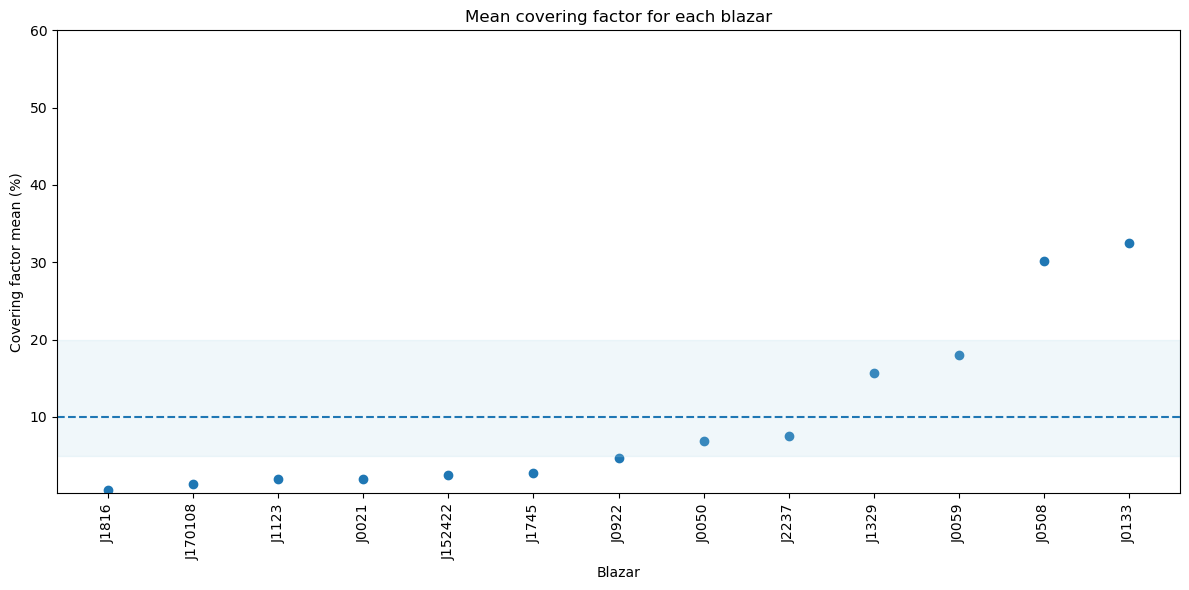

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Copia della tabella finale
df_plot = tabella_finale.copy()

# Converto Cf_mean in percentuale
df_plot["Cf_mean_percent"] = df_plot["Cf_mean"] * 100

# Se vuoi ordinare i blazar per valore di Cf
df_plot = df_plot.sort_values("Cf_mean_percent")

# Creo il grafico
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    df_plot["label"],
    df_plot["Cf_mean_percent"]
)

# linea orizzontale al 10%
ax.axhline(
    10,
    linestyle="--",
    linewidth=1.5
)

ax.axhspan(
    5,
    20,
    color="lightblue",
    alpha=0.18
)

ax.set_xlabel("Blazar")
ax.set_ylabel("Covering factor mean (%)")
# range dell'asse y
ax.set_ylim(0.1, 60)

# ruoto i nomi per leggerli meglio
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

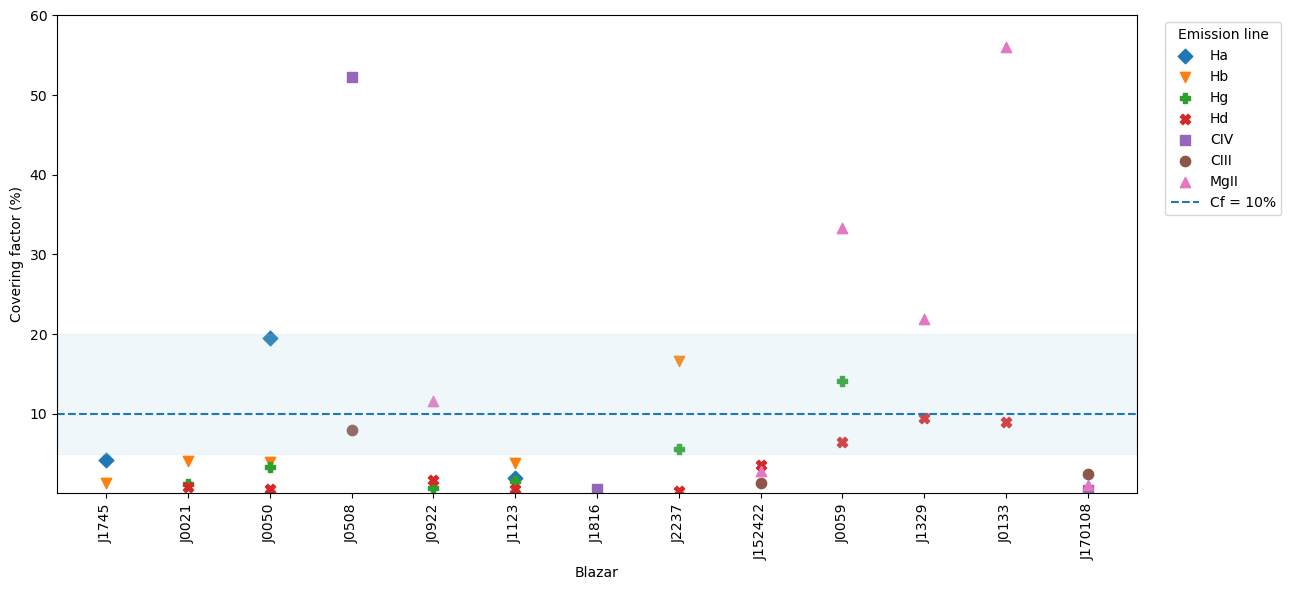

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Copia del dataframe linea-per-linea
df_plot = df_cf_mcmc.copy()

# Converto Cf in percentuale
df_plot["Cf_percent"] = df_plot["covering_factor"] * 100

# Ordine dei blazar
blazars = df_plot["label"].unique()
x_positions = np.arange(len(blazars))

# Mappa nome blazar -> posizione numerica sull'asse x
x_map = {name: i for i, name in enumerate(blazars)}

# Simboli diversi per le diverse righe
markers = {
    "CIII": "o",
    "CIV": "s",
    "MgII": "^",
    "Ha": "D",
    "Hb": "v",
    "Hg": "P",
    "Hd": "X"
}

fig, ax = plt.subplots(figsize=(13, 6))

# Disegno separatamente ciascuna riga
for line_name in df_plot["line_name"].unique():

    subset = df_plot[df_plot["line_name"] == line_name]

    x = [
        x_map[label]
        for label in subset["label"]
    ]

    y = subset["Cf_percent"]

    ax.scatter(
        x,
        y,
        marker=markers.get(line_name, "o"),
        s=55,
        label=line_name
    )

# Linea corrispondente al Cf assunto nell'MCMC
ax.axhline(
    10,
    linestyle="--",
    linewidth=1.5,
    label="Cf = 10%"
)

# Area tra 5 e 20 %
ax.axhspan(
    5,
    20,
    color="lightblue",
    alpha=0.18
)


# Asse x
ax.set_xticks(x_positions)
ax.set_xticklabels(
    blazars,
    rotation=90
)

# Etichette
ax.set_xlabel("Blazar")
ax.set_ylabel("Covering factor (%)")



# Range richiesto
ax.set_ylim(0.001, 60)

ax.legend(
    title="Emission line",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

-->   quelli con covering factor maggiore sono gli SS !!!!!!!!!! Forse SS non è modello corretto per descrivere blazar di transizione ?